# Stokes drift in the Kiel Bight

CMEMS Baltic wave analysis (cmems_mod_bal_wav_anfc_PT1H-i), 7 days
starting 2023-04-24. We look at surface Stokes drift to understand
the wave-driven component that a drogued drifter would experience.

In [1]:
import copernicusmarine as cm
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

/Users/wrath/src/github.com/geomar-od-lagrange/2025_drogued_drifters/.pixi/envs/default/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load data

First check what variables are available, then load the Stokes drift
components for the Kiel Bight region.

In [2]:
ds_full = cm.open_dataset(
    dataset_id="cmems_mod_bal_wav_anfc_PT1H-i",
    service="arco-geo-series",
)

ds = ds_full.sel(
    longitude=slice(9.5, 11.5),
    latitude=slice(54.0, 55.5),
    time=slice("2023-04-24", "2023-05-01"),
)[["VSDX", "VSDY", "VHM0", "VTPK"]].load()

# Evenly space coords so streamplot works
ds = ds.assign_coords(
    longitude=np.linspace(float(ds.longitude[0]), float(ds.longitude[-1]), len(ds.longitude)),
    latitude=np.linspace(float(ds.latitude[0]), float(ds.latitude[-1]), len(ds.latitude)),
)
ds

INFO - 2026-03-25T09:01:43Z - Selected dataset version: "202311"


INFO - 2026-03-25T09:01:43Z - Selected dataset part: "default"


<xarray.Dataset> Size: 20MB
Dimensions:    (time: 192, latitude: 90, longitude: 72)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2023-04-24 ... 2023-05-01T23:00:00
  * latitude   (latitude) float64 720B 54.01 54.02 54.04 ... 55.46 55.47 55.49
  * longitude  (longitude) float64 576B 9.514 9.542 9.569 ... 11.43 11.46 11.49
Data variables:
    VSDX       (time, latitude, longitude) float32 5MB nan nan nan ... nan nan
    VSDY       (time, latitude, longitude) float32 5MB nan nan nan ... nan nan
    VHM0       (time, latitude, longitude) float32 5MB nan nan nan ... nan nan
    VTPK       (time, latitude, longitude) float32 5MB nan nan nan ... nan nan
Attributes:
    Conventions:               CF-1.0
    cmems_product_id:          BALTICSEA_ANALYSISFORECAST_WAV_003_010
    easternmost_longitude:     30.2080
    grid_resolution:           1 nautical mile (ie. 0.0167 degrees northward;...
    institution:               Baltic MFC, PU Finnish Meteorological Institute
    northernmost_latitude:     65.9081
    source:                    FMI-WAM_CMEMS
    southernmost_latitude:     53.0083
    title:                     CMEMS WAM model fields (hourly)
    westernmost_longitude:     9.0138
    copernicusmarine_version:  2.3.0

In [3]:
# Stokes drift speed
ds["stokes_speed"] = np.sqrt(ds["VSDX"]**2 + ds["VSDY"]**2)

## Mean Stokes drift streamlines

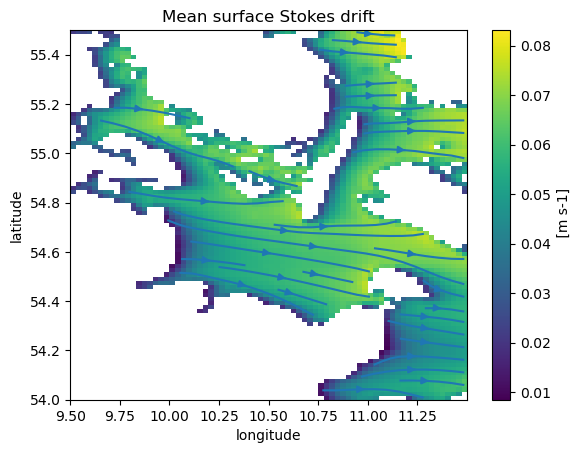

In [4]:
ds_mean = ds[["VSDX", "VSDY"]].mean("time")
speed_mean = np.sqrt(ds_mean["VSDX"]**2 + ds_mean["VSDY"]**2)

speed_mean.plot()
ds_mean.plot.streamplot(x="longitude", y="latitude", u="VSDX", v="VSDY")
plt.title("Mean surface Stokes drift")
plt.show()

## Maximum Stokes drift speed

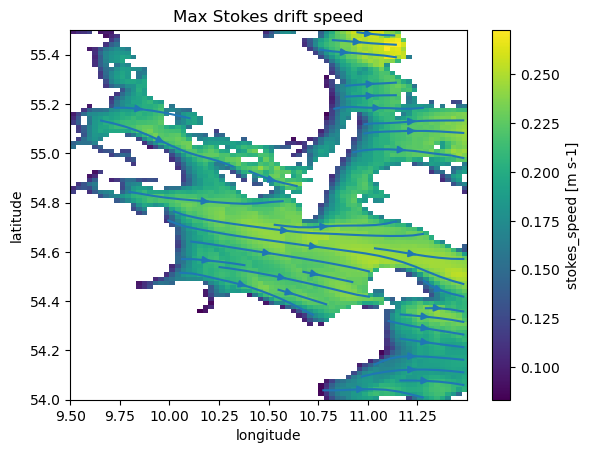

In [5]:
ds["stokes_speed"].max("time").plot()
ds_mean.plot.streamplot(x="longitude", y="latitude", u="VSDX", v="VSDY")
plt.title("Max Stokes drift speed")
plt.show()

## Stokes drift speed RMS

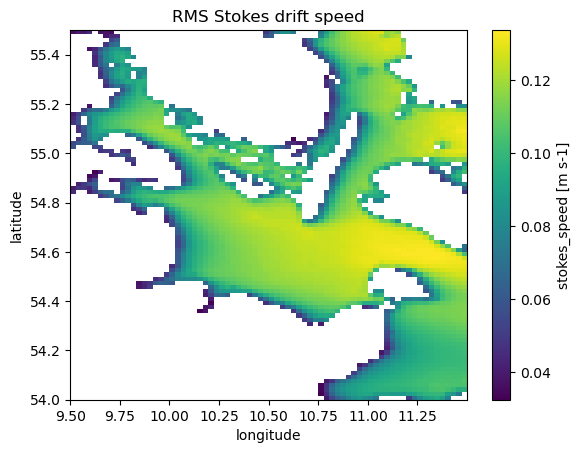

In [6]:
np.sqrt((ds["stokes_speed"]**2).mean("time")).plot()
plt.title("RMS Stokes drift speed")
plt.show()

## Summary statistics

In [7]:
speed = ds["stokes_speed"]
print(f"Surface Stokes drift speed:")
print(f"  Mean: {float(speed.mean()):.4f} m/s")
print(f"  RMS:  {float(np.sqrt((speed**2).mean())):.4f} m/s")
print(f"  Max:  {float(speed.max()):.4f} m/s")
print(f"  P95:  {float(speed.quantile(0.95)):.4f} m/s")

print(f"\nWave conditions:")
print(f"  Hs mean: {float(ds['VHM0'].mean()):.2f} m, max: {float(ds['VHM0'].max()):.2f} m")
print(f"  Tp mean: {float(ds['VTPK'].mean()):.1f} s, range: {float(ds['VTPK'].min()):.1f}–{float(ds['VTPK'].max()):.1f} s")

Tp = float(ds["VTPK"].mean())
H_e = 9.81 * Tp**2 / (8 * np.pi**2)
print(f"\nStokes e-folding depth (mean Tp={Tp:.1f}s): {H_e:.1f} m")

Surface Stokes drift speed:
  Mean: 0.0871 m/s
  RMS:  0.1035 m/s
  Max:  0.2727 m/s
  P95:  0.1862 m/s

Wave conditions:
  Hs mean: 0.47 m, max: 1.82 m
  Tp mean: 2.9 s, range: 0.9–5.7 s

Stokes e-folding depth (mean Tp=2.9s): 1.1 m
